In [11]:
!pip install sentence-transformers seaborn


In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
sentences = [
    "Cricket is a popular sport in India",
    "The bowler took a wicket",
    "The batsman scored a century",

    "Cooking requires patience and skill",
    "Boil water before adding rice",
    "Spices enhance the flavor of food",

    "Cybersecurity protects computer systems",
    "Hackers exploit system vulnerabilities",
    "Strong passwords improve security",

    "Data breaches can cause major damage"
]


In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
embeddings = model.encode(sentences)


In [16]:
similarity_matrix = np.inner(embeddings, embeddings)


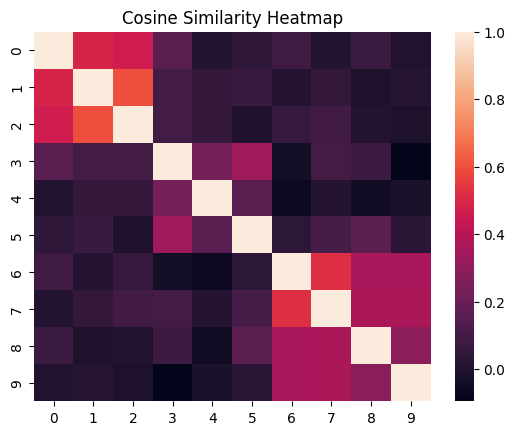

In [17]:
plt.figure()
sns.heatmap(similarity_matrix)
plt.title("Cosine Similarity Heatmap")
plt.show()


In [18]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = np.inner(query_embedding, embeddings)[0]

top2 = scores.argsort()[-2:][::-1]

for i in top2:
    print("Sentence:", sentences[i])
    print("Score:", scores[i])
    print()


Sentence: The bowler took a wicket
Score: 0.8484633

Sentence: The batsman scored a century
Score: 0.5602761

